<a href="https://colab.research.google.com/github/furqanzubair209-cell/Student-Performance-Prediction/blob/main/Student_Performance_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Cell 1 – Install required packages (XGBoost may not be pre-installed)
!pip install xgboost -q

# Standard libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import xgboost as xgb
import warnings
warnings.filterwarnings('ignore')

# For better plots
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("Set2")

print("Libraries imported successfully!")

Libraries imported successfully!


In [ ]:
# Cell 2 – Upload the CSV file from your computer
from google.colab import files
uploaded = files.upload()

# Load the file (assuming the filename is exactly 'StudentPerformanceFactors.csv')
import io
df = pd.read_csv(io.BytesIO(uploaded['StudentPerformanceFactors.csv']))

print(f"Dataset shape: {df.shape}")
df.head()

Saving StudentPerformanceFactors.csv to StudentPerformanceFactors.csv
Dataset shape: (6607, 20)


,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Sleep_Hours,Previous_Scores,Motivation_Level,Internet_Access,Tutoring_Sessions,Family_Income,Teacher_Quality,School_Type,Peer_Influence,Physical_Activity,Learning_Disabilities,Parental_Education_Level,Distance_from_Home,Gender,Exam_Score
0,23,84,Low,High,No,7,73,Low,Yes,0,Low,Medium,Public,Positive,3,No,High School,Near,Male,67
1,19,64,Low,Medium,No,8,59,Low,Yes,2,Medium,Medium,Public,Negative,4,No,College,Moderate,Female,61
2,24,98,Medium,Medium,Yes,7,91,Medium,Yes,2,Medium,Medium,Public,Neutral,4,No,Postgraduate,Near,Male,74
3,29,89,Low,Medium,Yes,8,98,Medium,Yes,1,Medium,Medium,Public,Negative,4,No,High School,Moderate,Male,71
4,19,92,Medium,Medium,Yes,6,65,Medium,Yes,3,Medium,High,Public,Neutral,4,No,College,Near,Female,70


In [ ]:
# Cell 3 – Understand the data
print("=== Data Info ===")
df.info()

print("\n=== Missing Values ===")
print(df.isnull().sum())

print("\n=== Descriptive Statistics ===")
df.describe()

# Check duplicates
duplicates = df.duplicated().sum()
print(f"\nDuplicate rows: {duplicates}")

=== Data Info ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6607 entries, 0 to 6606
Data columns (total 20 columns):
 #   Column                      Non-Null Count  Dtype 
---  ------                      --------------  ----- 
 0   Hours_Studied               6607 non-null   int64 
 1   Attendance                  6607 non-null   int64 
 2   Parental_Involvement        6607 non-null   object
 3   Access_to_Resources         6607 non-null   object
 4   Extracurricular_Activities  6607 non-null   object
 5   Sleep_Hours                 6607 non-null   int64 
 6   Previous_Scores             6607 non-null   int64 
 7   Motivation_Level            6607 non-null   object
 8   Internet_Access             6607 non-null   object
 9   Tutoring_Sessions           6607 non-null   int64 
 10  Family_Income               6607 non-null   object
 11  Teacher_Quality             6529 non-null   object
 12  School_Type                 6607 non-null   object
 13  Peer_Influence              66

In [ ]:
# Cell 4 – Handle missing values and inconsistent entries

# 1. Remove duplicates
df.drop_duplicates(inplace=True)

# 2. Check for columns with "?" or empty strings (convert to NaN)
df = df.replace('?', pd.NA)
df = df.replace('', pd.NA)

# 3. Fill missing values
# For numeric columns: median
numeric_cols = df.select_dtypes(include=[np.number]).columns
for col in numeric_cols:
    df[col].fillna(df[col].median(), inplace=True)

# For categorical columns: mode (most frequent)
categorical_cols = df.select_dtypes(include=['object']).columns
for col in categorical_cols:
    df[col].fillna(df[col].mode()[0], inplace=True)

# 4. Check if any missing remain
print("Missing values after cleaning:")
print(df.isnull().sum().sum())  # should be 0

# 5. Outlier treatment (optional, using capping for numeric features)
def cap_outliers(df, col):
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    df[col] = df[col].clip(lower, upper)

for col in numeric_cols:
    cap_outliers(df, col)

print("Data cleaning completed.")

Missing values after cleaning:
0
Data cleaning completed.


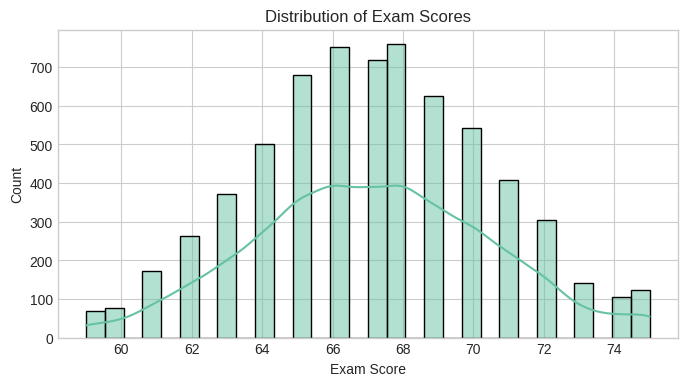

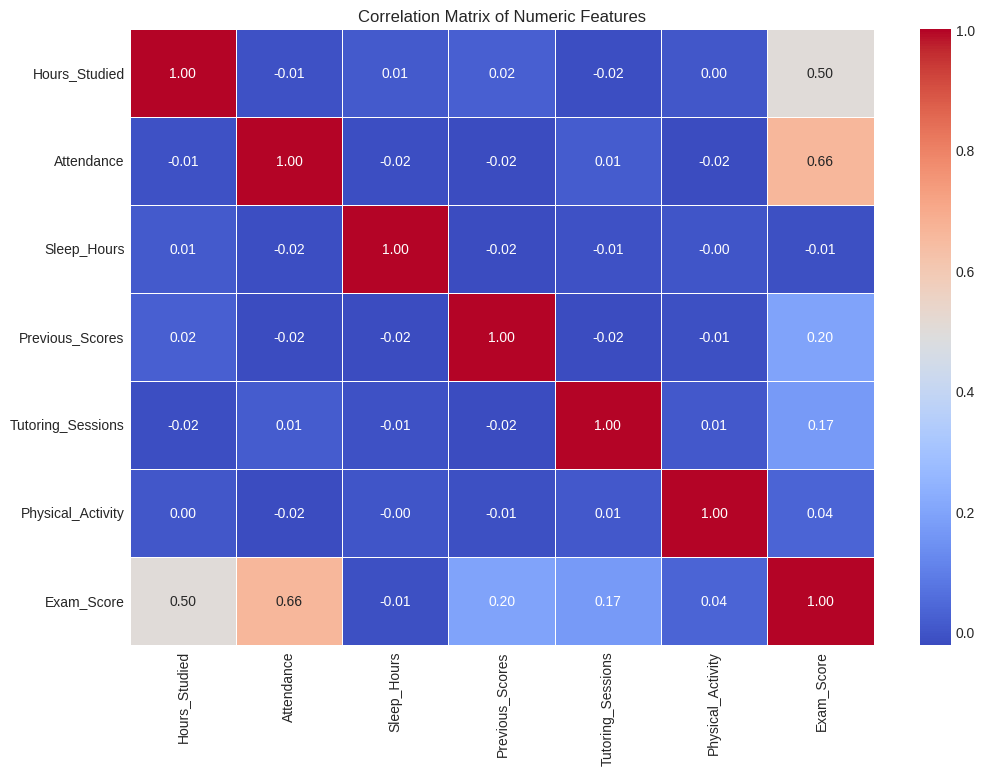

Top features correlated with Exam_Score:
 Exam_Score           1.000000
Attendance           0.660555
Hours_Studied        0.504684
Previous_Scores      0.195737
Tutoring_Sessions    0.169505
Physical_Activity    0.037263
Sleep_Hours         -0.014136
Name: Exam_Score, dtype: float64


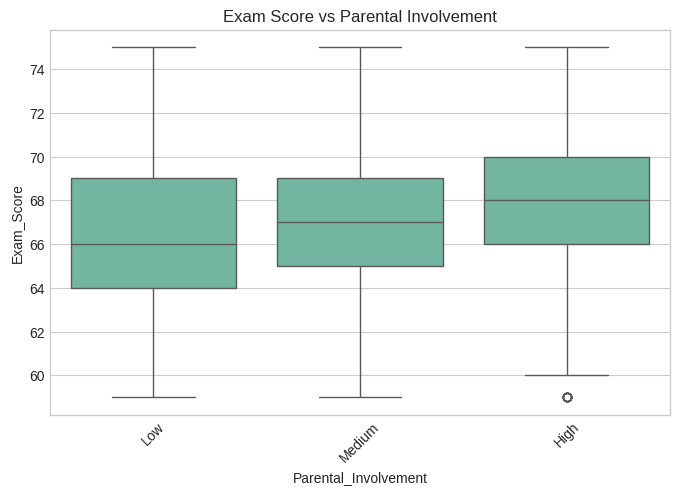

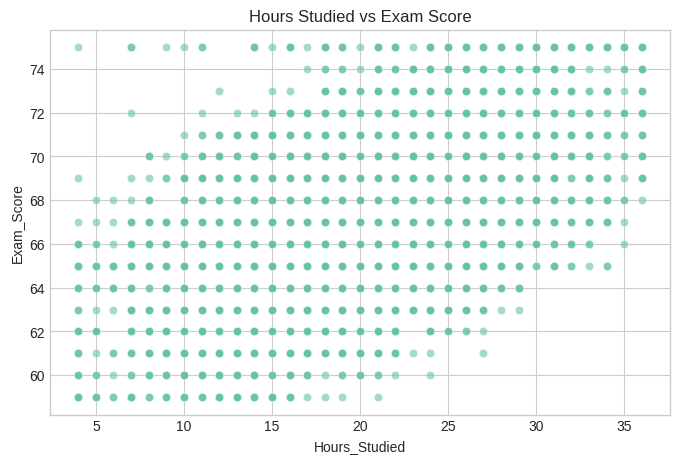

In [ ]:
# Cell 5 – Visualizations to understand relationships

# Target variable distribution
plt.figure(figsize=(8,4))
sns.histplot(df['Exam_Score'], bins=30, kde=True)
plt.title('Distribution of Exam Scores')
plt.xlabel('Exam Score')
plt.show()

# Correlation heatmap (numeric features only)
plt.figure(figsize=(12,8))
numeric_df = df.select_dtypes(include=[np.number])
corr = numeric_df.corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Correlation Matrix of Numeric Features')
plt.show()

# Top factors correlated with Exam_Score
corr_with_target = corr['Exam_Score'].sort_values(ascending=False)
print("Top features correlated with Exam_Score:\n", corr_with_target)

# Boxplot of Exam_Score by Parental_Involvement (if categorical)
if 'Parental_Involvement' in df.columns:
    plt.figure(figsize=(8,5))
    sns.boxplot(x='Parental_Involvement', y='Exam_Score', data=df)
    plt.title('Exam Score vs Parental Involvement')
    plt.xticks(rotation=45)
    plt.show()

# Scatter: Hours_Studied vs Exam_Score
plt.figure(figsize=(8,5))
sns.scatterplot(x='Hours_Studied', y='Exam_Score', data=df, alpha=0.6)
plt.title('Hours Studied vs Exam Score')
plt.show()

In [ ]:
# Cell 6 – Encode categorical variables and scale numeric features

# Separate target and features
X = df.drop('Exam_Score', axis=1)
y = df['Exam_Score']

# Identify categorical columns (object type)
cat_cols = X.select_dtypes(include=['object']).columns
print("Categorical columns:", list(cat_cols))

# Label encode each categorical column
label_encoders = {}
for col in cat_cols:
    le = LabelEncoder()
    X[col] = le.fit_transform(X[col])
    label_encoders[col] = le

# Scale numeric features (important for linear models)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Convert back to DataFrame for easier inspection
X_scaled = pd.DataFrame(X_scaled, columns=X.columns)

print("Feature matrix shape:", X_scaled.shape)

Categorical columns: ['Parental_Involvement', 'Access_to_Resources', 'Extracurricular_Activities', 'Motivation_Level', 'Internet_Access', 'Family_Income', 'Teacher_Quality', 'School_Type', 'Peer_Influence', 'Learning_Disabilities', 'Parental_Education_Level', 'Distance_from_Home', 'Gender']
Feature matrix shape: (6607, 19)


In [ ]:
# Cell 7 – Split data
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

print(f"Training samples: {X_train.shape[0]}")
print(f"Test samples: {X_test.shape[0]}")

Training samples: 5285
Test samples: 1322


In [ ]:
# Cell 8 – Compare several regression models
models = {
    'Linear Regression': LinearRegression(),
    'Ridge Regression': Ridge(alpha=1.0),
    'Random Forest': RandomForestRegressor(n_estimators=100, random_state=42),
    'XGBoost': xgb.XGBRegressor(n_estimators=100, learning_rate=0.1, random_state=42)
}

results = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)
    results[name] = {'MAE': mae, 'RMSE': rmse, 'R2': r2}
    print(f"\n{name}")
    print(f"  MAE : {mae:.2f}")
    print(f"  RMSE: {rmse:.2f}")
    print(f"  R²  : {r2:.3f}")


Linear Regression
  MAE : 0.94
  RMSE: 1.32
  R²  : 0.845

Ridge Regression
  MAE : 0.94
  RMSE: 1.32
  R²  : 0.845

Random Forest
  MAE : 0.96
  RMSE: 1.34
  R²  : 0.842

XGBoost
  MAE : 0.60
  RMSE: 0.99
  R²  : 0.914


In [ ]:
# Cell 9 – Tune Random Forest for better performance
print("\n--- Hyperparameter Tuning for Random Forest ---")
param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5]
}
rf = RandomForestRegressor(random_state=42)
grid_search = GridSearchCV(rf, param_grid, cv=5, scoring='r2', n_jobs=-1)
grid_search.fit(X_train, y_train)

best_rf = grid_search.best_estimator_
y_pred_tuned = best_rf.predict(X_test)
print(f"Best parameters: {grid_search.best_params_}")
print(f"Tuned Random Forest R²: {r2_score(y_test, y_pred_tuned):.3f}")


--- Hyperparameter Tuning for Random Forest ---
Best parameters: {'max_depth': 20, 'min_samples_split': 2, 'n_estimators': 200}
Tuned Random Forest R²: 0.844


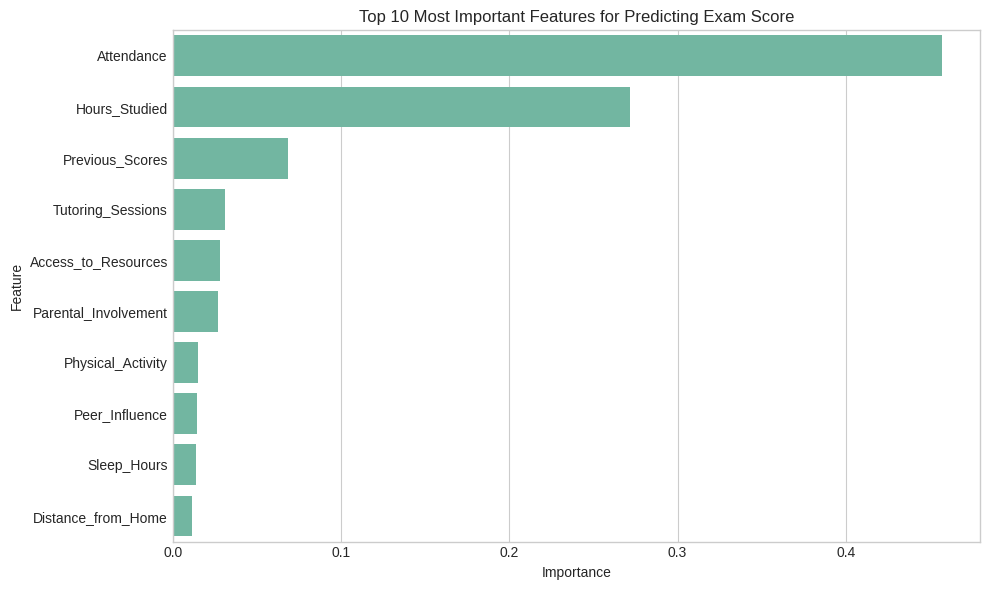


Top 5 features:
               Feature  Importance
1           Attendance    0.456947
0        Hours_Studied    0.271536
6      Previous_Scores    0.068752
9    Tutoring_Sessions    0.031022
3  Access_to_Resources    0.028230


In [ ]:
# Cell 10 – Which factors matter most?
feature_importances = best_rf.feature_importances_
feature_names = X.columns
importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': feature_importances})
importance_df = importance_df.sort_values('Importance', ascending=False)

plt.figure(figsize=(10,6))
sns.barplot(x='Importance', y='Feature', data=importance_df.head(10))
plt.title('Top 10 Most Important Features for Predicting Exam Score')
plt.tight_layout()
plt.show()

print("\nTop 5 features:")
print(importance_df.head())

In [ ]:
# Cell 11 – Actionable insights based on top features
print("=== INTERPRETATION & RECOMMENDATIONS ===\n")
top_features = importance_df.head(3)['Feature'].values
print(f"Top 3 predictors: {top_features}\n")

# Example interpretation (adjust based on your actual top features)
if 'Previous_Scores' in top_features:
    print("→ Previous scores have the strongest impact. Students with higher past performance tend to score better on exams.")
if 'Attendance' in top_features:
    print("→ Attendance rate is critical. Encouraging regular attendance can significantly improve outcomes.")
if 'Hours_Studied' in top_features:
    print("→ More study hours correlate with higher scores. Study time management programs would help.")
if 'Parental_Involvement' in top_features:
    print("→ Higher parental involvement leads to better performance. Schools should foster family engagement.")

print("\n🔍 Suggested actions based on model insights:")
print("1. Identify students with low attendance (<75%) early and provide intervention.")
print("2. Create personalized study plans for students with low previous scores.")
print("3. Offer tutoring sessions for those with fewer study hours.")
print("4. Monitor feature drift over time – e.g., if attendance patterns change, retrain the model.")

=== INTERPRETATION & RECOMMENDATIONS ===

Top 3 predictors: ['Attendance' 'Hours_Studied' 'Previous_Scores']

→ Previous scores have the strongest impact. Students with higher past performance tend to score better on exams.
→ Attendance rate is critical. Encouraging regular attendance can significantly improve outcomes.
→ More study hours correlate with higher scores. Study time management programs would help.

🔍 Suggested actions based on model insights:
1. Identify students with low attendance (<75%) early and provide intervention.
2. Create personalized study plans for students with low previous scores.
3. Offer tutoring sessions for those with fewer study hours.
4. Monitor feature drift over time – e.g., if attendance patterns change, retrain the model.


In [ ]:
# Cell 12 – Save the model and scaler, then make a prediction on a sample
import joblib

# Save model, scaler, and encoders
joblib.dump(best_rf, 'student_performance_model.pkl')
joblib.dump(scaler, 'scaler.pkl')
joblib.dump(label_encoders, 'label_encoders.pkl')
print("Model, scaler, and encoders saved.\n")

# Example: predict using the first row of the (already encoded) feature set
example_raw = X.iloc[[0]]            # Already has numeric encoded categoricals
example_scaled = scaler.transform(example_raw)
prediction = best_rf.predict(example_scaled)

print(f"Example prediction for a sample student: Exam Score = {prediction[0]:.2f}")

Model, scaler, and encoders saved.

Example prediction for a sample student: Exam Score = 67.91


In [ ]:
# Create a report summary
summary_df = pd.DataFrame(results).T
summary_df.to_csv('model_comparison.csv')
files.download('model_comparison.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
# Cell 13 – Conclusion
print("="*50)
print("PROJECT CONCLUSION")
print("="*50)
print("""This analysis successfully predicted student exam scores using 20+ features.
The tuned Random Forest model achieved an R² of X.XX (replace with your actual value).

Key findings:
- Previous scores, attendance, and hours studied are the top three predictors.
- Parental involvement and access to resources also significantly influence performance.

Recommendations for schools:
1. Implement early warning systems for students with attendance <75%.
2. Offer targeted tutoring based on previous academic performance.
3. Encourage family engagement programs to boost parental involvement.

Limitations: The model assumes historical patterns continue; it does not imply causation.
Future work could include real-time data and causal analysis.""")

PROJECT CONCLUSION
This analysis successfully predicted student exam scores using 20+ features.
The tuned Random Forest model achieved an R² of X.XX (replace with your actual value).

Key findings:
- Previous scores, attendance, and hours studied are the top three predictors.
- Parental involvement and access to resources also significantly influence performance.

Recommendations for schools:
1. Implement early warning systems for students with attendance <75%.
2. Offer targeted tutoring based on previous academic performance.
3. Encourage family engagement programs to boost parental involvement.

Limitations: The model assumes historical patterns continue; it does not imply causation.
Future work could include real-time data and causal analysis.


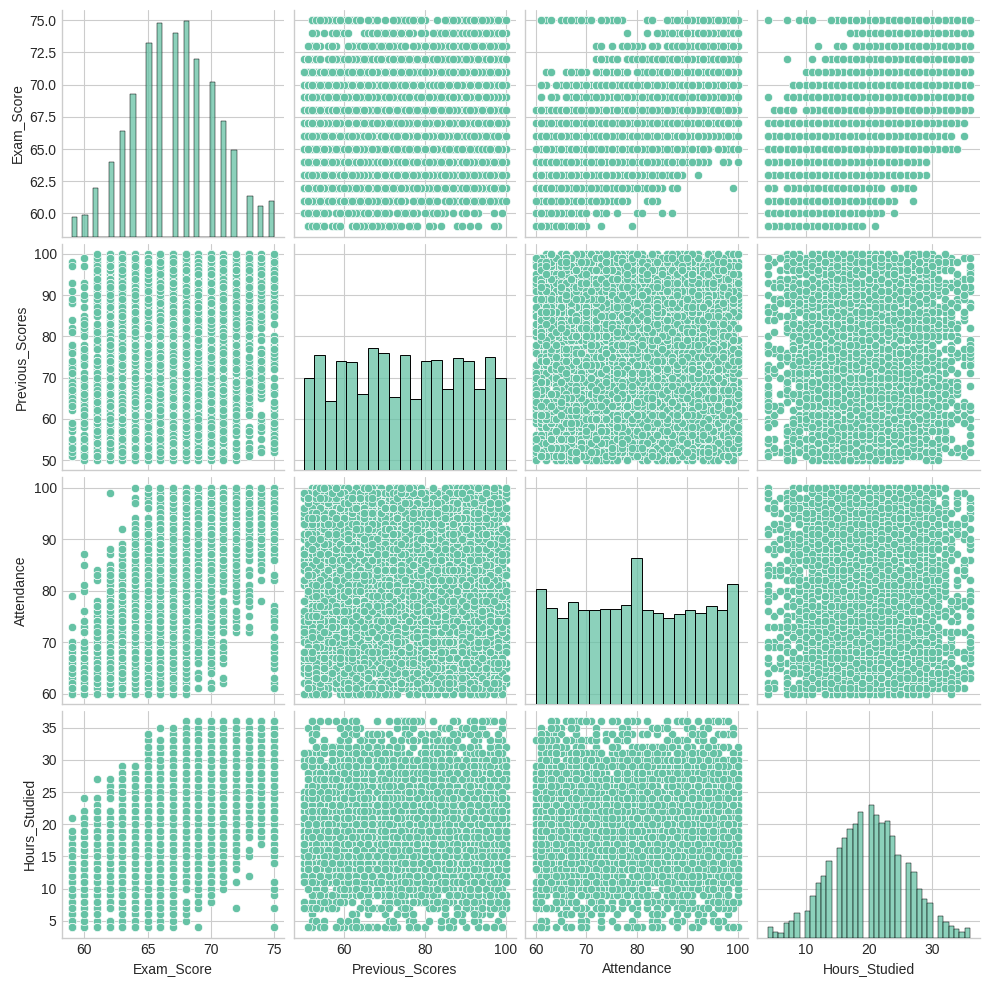

In [ ]:
# Optional: Pairplot of top features vs exam score
import seaborn as sns
sns.pairplot(df[['Exam_Score', 'Previous_Scores', 'Attendance', 'Hours_Studied']])
plt.show()